Changes compared to v4 implementation:
- Optimizer implemented with litellm completion API in pdf_agent_fast_n_slow.py
- Python code interpreter tool enhancements:
  - Enhanced the python code interpreter tool error handling (wrap the last line in a print statement if not already + remove incorrect indentation if whitespace number is not a multiple of 2)
  - Enhanced the python code interpreter tool to handle the case where the last line is a variable (e.g. "mineral_resource_tonnage" -> "print(mineral_resource_tonnage)")
  - Return when state["remaining_steps"] < 2 to avoid recurrsion error

In [10]:
import re
from collections import Counter
from operator import add
from typing import Annotated, Any, List, Optional

import chromadb
import tiktoken
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain.text_splitter import MarkdownHeaderTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.graph import END, START, StateGraph
from langgraph.pregel import RetryPolicy
from openai import OpenAI
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from agent_k.agents.code_agent_react import react_agent
from agent_k.config.logger import logger
from agent_k.config.prompts_fast_n_slow import (
    DEEP_EXTRACT_SYSTEM_PROMPT,
    GENERATION_USER_PROMPT_W_FEEDBACK,
    GRADE_DOCUMENTS_SYSTEM_PROMPT,
    GRADE_HALLUCINATION_SYSTEM_PROMPT,
    GRADE_HALLUCINATION_USER_PROMPT,
    QUESTION_REWRITER_SYSTEM_PROMPT,
    QUESTION_REWRITER_USER_PROMPT,
    QUESTION_TEMPLATE,
)
from agent_k.config.schemas import (
    TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
)

load_dotenv()

# Retry for generate node (code interpreter easily fails)
RETRY_POLICY = RetryPolicy(max_attempts=3)

CLIENT = OpenAI()
NUM_RETRIEVED_DOCS = 5
GRADE_RETRIEVAL_MODEL = "gpt-4o-mini"
GRADE_RETRIEVAL_TEMPERATURE = 0.1
PYTHON_AGENT_MODEL = "gpt-4o-mini"
GRADE_HALLUCINATION_MODEL = "gpt-4o-mini"
QUESTION_REWRITER_MODEL = "gpt-4o-mini"
QUESTION_REWRITER_TEMPERATURE = 0.5
REACT_AGENT_RECURSION_LIMIT = 10


def count_tokens(text):
    encoding = tiktoken.get_encoding("cl100k_base")
    return len(encoding.encode(text))


def create_markdown_retriever(
    markdown_path: str,
    collection_name: str,
    headers_to_split_on: Optional[list[tuple[str, str]]] = None,
    embedding_model: str = "text-embedding-3-small",
) -> Chroma:
    """
    Creates a Chroma retriever from a markdown document.

    Args:
        markdown_path: Path to the markdown file
        collection_name: Name for the Chroma collection
        headers_to_split_on: List of tuples containing markdown header levels and their names
        embedding_model: Name of the OpenAI embedding model to use

    Returns:
        Chroma retriever object
    """
    # Set default headers if none provided
    if headers_to_split_on is None:
        headers_to_split_on = [
            ("#", "Header 1"),
            ("##", "Header 2"),
            ("###", "Header 3"),
        ]

    # Read markdown file
    try:
        with open(markdown_path, "r", encoding="utf-8") as file:
            markdown_document = file.read()
    except Exception as e:
        logger.error(f"Error reading markdown file: {e}")
        raise

    # Split document
    markdown_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=headers_to_split_on
    )
    doc_splits = markdown_splitter.split_text(markdown_document)

    # Log splitting information
    try:
        markdown_document_tokens = count_tokens(markdown_document)
        doc_splits_len = len(doc_splits)
        avg_tokens = markdown_document_tokens / doc_splits_len

        logger.info(f"Number of tokens: {markdown_document_tokens}")
        logger.info(f"Number of splits: {doc_splits_len}")
        logger.info(f"Average tokens per split: {avg_tokens:.0f}")
    except Exception as e:
        logger.warning(f"Could not log token statistics: {e}")

    # Create vectorstore and retriever
    try:
        # Initialize the Chroma client
        client = chromadb.Client()

        # Hash the collection name to determine which of 10 collections to use
        collection_hash = hash(collection_name)
        collection_index = abs(collection_hash) % 10  # Get value between 0-9
        hashed_collection_name = f"rag-chroma_shard_{collection_index}"
        logger.info(f"Hashed collection name: {hashed_collection_name}")

        # Delete existing in-memory collection if it exists
        try:
            client.delete_collection(hashed_collection_name)
            logger.info(f"Deleted existing collection: {hashed_collection_name}")
        except Exception:
            pass

        # Create a new vectorstore with persist_directory=None to keep it in-memory
        vectorstore = Chroma.from_documents(
            documents=doc_splits,
            collection_name=hashed_collection_name,
            embedding=OpenAIEmbeddings(model=embedding_model),
            persist_directory=None,  # Keep in-memory to avoid persistence
        )

        retriever = vectorstore.as_retriever(search_kwargs={"k": NUM_RETRIEVED_DOCS})
        return retriever
    except Exception as e:
        logger.error(f"Error creating retriever: {e}")
        raise

In [11]:
### Retrieval Grader
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    reasoning: str = Field(
        description="Reasoning why the document is relevant to the question or not"
    )
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model=GRADE_RETRIEVAL_MODEL, temperature=GRADE_RETRIEVAL_TEMPERATURE)
structured_llm_grader = llm.with_structured_output(GradeDocuments)


grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", GRADE_DOCUMENTS_SYSTEM_PROMPT),
        ("human", "# Retrieved document\n{document}\n\n# User question\n{question}"),
    ]
)

template = "# Retrieved document\n{document}\n\n# User question\n{question}"

retrieval_grader = grade_prompt | structured_llm_grader

In [12]:
### Generate


def deep_extract_w_feedback(question, context, previous_messages) -> str:
    # Convert previous messages to a list of strings from a list of dicts
    previous_messages_str = [str(msg) for msg in previous_messages]
    result = react_agent(
        DEEP_EXTRACT_SYSTEM_PROMPT,
        GENERATION_USER_PROMPT_W_FEEDBACK.format(
            question=question,
            context=context,
            previous_messages="\n".join(previous_messages_str),
        ),
        recursion_limit=REACT_AGENT_RECURSION_LIMIT,
    )
    content = result["messages"][-1].content

    return content

In [13]:
### Hallucination Grader

# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    feedback: str = Field(
        description="Reasoning whether the raw facts in the answer are aligned with the retrieved documents + feedback on how to improve"
    )
    binary_score: str = Field(
        description="Raw facts in the answer are aligned with the retrieved documents, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model=GRADE_HALLUCINATION_MODEL)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)


hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", GRADE_HALLUCINATION_SYSTEM_PROMPT),
        ("human", GRADE_HALLUCINATION_USER_PROMPT),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader

In [14]:
### Question Re-writer

# LLM
llm = ChatOpenAI(
    model=QUESTION_REWRITER_MODEL, temperature=QUESTION_REWRITER_TEMPERATURE
)

# Prompt
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", QUESTION_REWRITER_SYSTEM_PROMPT),
        ("human", QUESTION_REWRITER_USER_PROMPT),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()

# Graph

In [15]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

    # Added by Yixin
    retriever: Any
    hallucination_grade: str
    messages: Annotated[list[str], add]  # store prev generation + feedback
    previous_answers: Annotated[list[str], add]  # store prev ans for self consistency

In [16]:
### Nodes


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    logger.info("---RETRIEVE---")
    question = state["question"]

    # Regex parse lines start with "**Question" and "**Description"
    question_line = re.search(r"^.*?Question\s*(.*?)\s*$", question, re.DOTALL)
    description_line = re.search(r"^.*?Description\s*(.*?)\s*$", question, re.DOTALL)

    if question_line:
        question = question_line.group(1).strip()

    if description_line:
        description = description_line.group(1).strip()

    question = f"{question}\n\n{description}"

    # Retrieval
    documents = state["retriever"].invoke(question)

    return {"documents": documents}


def get_mode_or_last(lst):
    """
    Helper function to get the mode or last item of a list (used for self consistency)
    """
    count = Counter(lst)
    max_count = max(count.values())

    # Check if the mode is unique
    modes = [item for item, cnt in count.items() if cnt == max_count]

    if max_count > 1 and len(modes) == 1:
        return modes[0]
    else:
        return lst[-1]


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    logger.info("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    if len(state["previous_answers"]) >= 3:
        # Self consistency if detected looping
        mode_answer = get_mode_or_last(state["previous_answers"])
        generation = f"<reasoning>Detect looping. Use self consistency to choose the most popular answer from previous generations.</reasoning><answer>{mode_answer}</answer>"
    else:
        previous_messages = state["messages"]
        generation = deep_extract_w_feedback(question, documents, previous_messages)

    try:
        parsed_output = generation.split("<answer>")[1].split("</answer>")[0].strip()
        parsed_output = re.sub(r"[^0-9.]", "", parsed_output)
    except IndexError as e:
        logger.error(f"Error parsing <answer> XML tags for content: {generation}")
        raise e

    return {
        "generation": generation,
        "previous_answers": [parsed_output],
        "messages": [
            {"role": "Assistant", "content": generation},
        ],
    }


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    logger.info("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            logger.info("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            logger.info("---GRADE: DOCUMENT NOT RELEVANT---")
            continue

    return {"documents": filtered_docs}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    logger.info("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def check_hallucination(state):
    """
    First node: Check if generation is grounded in documents.

    Args:
        state (dict): The current graph state
    Returns:
        dict: State updates and next node
    """
    logger.info("---CHECK HALLUCINATIONS---")
    documents = state["documents"]
    generation = state["generation"]
    previous_messages = state["messages"]

    score: GradeHallucinations = hallucination_grader.invoke(
        {
            "documents": documents,
            "generation": generation,
            "previous_messages": previous_messages,
        }
    )
    grade = score.binary_score
    hallucination_grader_feedback = score.feedback
    return {
        "hallucination_grade": grade,
        "messages": [
            {
                "role": "Hallucination Grader",
                "content": f"Passed hallucination check: {grade}\nFeedback: {hallucination_grader_feedback}",
            }
        ],
    }


### Edges


def retriever_router(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    logger.info("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        logger.info(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        logger.info("---DECISION: GENERATE---")
        return "generate"


def hallucination_router(state):
    """
    Route based on hallucination check result
    """
    if state["hallucination_grade"].lower() == "yes":
        logger.info(
            "---DECISION: GENERATION IS GROUNDED IN DOCUMENTS (NO HALLUCINATION)---"
        )
        return END
    elif len(state["previous_answers"]) >= 3:
        logger.info("---DECISION: LOOPING DETECT. USE SELF CONSISTENCY VALUE. END---")
        return END
    else:
        logger.info(
            "---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY (HALLUCINATION)---"
        )
        return "regenerate"


def answer_quality_router(state):
    """
    Route based on answer quality check result
    """
    if state["answer_grade"] == "yes":
        logger.info("---DECISION: GENERATION ADDRESSES QUESTION---")
        return "useful"
    else:
        logger.info("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
        return "regenerate"

## Build Graph


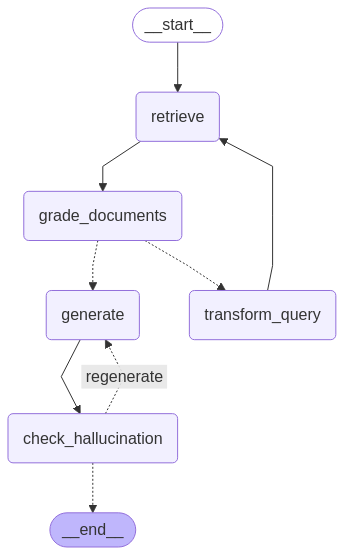

In [17]:
def viz_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        pass


self_rag_graph_builder = StateGraph(GraphState)

# Define the nodes
self_rag_graph_builder.add_node("retrieve", retrieve)
self_rag_graph_builder.add_node("grade_documents", grade_documents)
self_rag_graph_builder.add_node("generate", generate, retry=RETRY_POLICY)
self_rag_graph_builder.add_node("transform_query", transform_query)
self_rag_graph_builder.add_node("check_hallucination", check_hallucination)

# Build graph
self_rag_graph_builder.add_edge(START, "retrieve")
self_rag_graph_builder.add_edge("retrieve", "grade_documents")
self_rag_graph_builder.add_conditional_edges(
    "grade_documents",
    retriever_router,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
# self_rag_graph_builder.add_edge("generate", "check_hallucination")
self_rag_graph_builder.add_edge("generate", "check_hallucination")
self_rag_graph_builder.add_edge("transform_query", "retrieve")
self_rag_graph_builder.add_conditional_edges(
    "check_hallucination",
    hallucination_router,
    {
        END: END,
        "regenerate": "generate",
    },
)

# Compile
self_rag_graph = self_rag_graph_builder.compile()

# Visualize the graph
viz_graph(self_rag_graph)

In [18]:
# Run
if __name__ == "__main__":
    question = QUESTION_TEMPLATE.format(
        field="total_mineral_resource_tonnage",
        # field="total_mineral_reserve_contained_metal",
        dtype="float",
        default=0,
        description=TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
        # description=TOTAL_MINERAL_RESERVE_CONTAINED_METAL_DESCRIPTION.replace(
        #     "<main_commodity>", "nickel"
        # ),
    )

    retriever = create_markdown_retriever(
        "data/processed/43-101-refined/0200a1c6d2cfafeb485d815d95966961d4c119e8662b8babec74e05b59ba4759d2.md",
        collection_name="rag-chroma",
    )

    graph_inputs = {
        "question": question,
        "generation": "N/A",
        "retriever": retriever,
        "hallucination_grade": "N/A",
    }

    value = self_rag_graph.invoke(graph_inputs, config={"recursion_limit": 12})

    # Final generation
    logger.info("---FINAL GENERATION---")
    logger.info(value["generation"])

2025-04-23 17:22:51.795 | INFO     | __main__:create_markdown_retriever:104 - Number of tokens: 49301
2025-04-23 17:22:51.796 | INFO     | __main__:create_markdown_retriever:105 - Number of splits: 49
2025-04-23 17:22:51.797 | INFO     | __main__:create_markdown_retriever:106 - Average tokens per split: 1006


2025-04-23 17:22:51.798 | INFO     | __main__:create_markdown_retriever:119 - Hashed collection name: rag-chroma_shard_2
2025-04-23 17:22:53.867 | INFO     | __main__:retrieve:14 - ---RETRIEVE---
2025-04-23 17:22:54.282 | INFO     | __main__:grade_documents:100 - ---CHECK DOCUMENT RELEVANCE TO QUESTION---
2025-04-23 17:22:55.701 | INFO     | __main__:grade_documents:115 - ---GRADE: DOCUMENT NOT RELEVANT---
2025-04-23 17:22:56.933 | INFO     | __main__:grade_documents:115 - ---GRADE: DOCUMENT NOT RELEVANT---
2025-04-23 17:22:58.176 | INFO     | __main__:grade_documents:112 - ---GRADE: DOCUMENT RELEVANT---
2025-04-23 17:22:59.633 | INFO     | __main__:grade_documents:112 - ---GRADE: DOCUMENT RELEVANT---
2025-04-23 17:23:00.894 | INFO     | __main__:grade_documents:112 - ---GRADE: DOCUMENT RELEVANT---
2025-04-23 17:23:00.896 | INFO     | __main__:retriever_router:189 - ---ASSESS GRADED DOCUMENTS---
2025-04-23 17:23:00.897 | INFO     | __main__:retriever_router:202 - ---DECISION: GENERATE-